# Lista 2

**Aluno: Kauê Patricius Montgomery Maranhão da Costa Montenegro**
\
**Nome da base: Melb_data.csv**

## Orientações

- Escolha apenas uma das bases disponíveis e resolva todas as 10 questões usando essa mesma base.
- Desenvolva toda a atividade em Python, no formato de entrega do Google Colab.
- Organize o notebook por questão, com códigos executáveis, saídas geradas e comentários objetivos.
- Não troque de base ao longo da atividade.
- Não faça tratamento manual linha por linha.
- Sempre que necessário, sustente suas decisões com tabelas, métricas, gráficos e resultados do código.

## Importação das bibliotecas

In [25]:
# Bibliotecas principais
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Modelagem e pré-processamento
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler, LabelEncoder
from sklearn.impute import SimpleImputer
from sklearn.naive_bayes import GaussianNB, MultinomialNB, BernoulliNB
from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor, plot_tree
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report,
    mean_absolute_error, mean_squared_error, r2_score
)

# Bibliotecas auxiliares para visualização e redes
import networkx as nx

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 5)

## Carregamento da base

In [26]:
# Carregamento da base
# Substitua o nome do arquivo pelo arquivo correto da base escolhida
df = pd.read_csv('melb_data.csv')

# Visualização inicial
df.head()

,Suburb,Address,Rooms,Type,Price,Method,SellerG,Date,Distance,Postcode,...,Bathroom,Car,Landsize,BuildingArea,YearBuilt,CouncilArea,Lattitude,Longtitude,Regionname,Propertycount
0,Abbotsford,85 Turner St,2,h,1480000.0,S,Biggin,3/12/2016,2.5,3067.0,...,1.0,1.0,202.0,NaN,NaN,Yarra,-37.7996,144.9984,Northern Metropolitan,4019.0
1,Abbotsford,25 Bloomburg St,2,h,1035000.0,S,Biggin,4/02/2016,2.5,3067.0,...,1.0,0.0,156.0,79.0,1900.0,Yarra,-37.8079,144.9934,Northern Metropolitan,4019.0
2,Abbotsford,5 Charles St,3,h,1465000.0,SP,Biggin,4/03/2017,2.5,3067.0,...,2.0,0.0,134.0,150.0,1900.0,Yarra,-37.8093,144.9944,Northern Metropolitan,4019.0
3,Abbotsford,40 Federation La,3,h,850000.0,PI,Biggin,4/03/2017,2.5,3067.0,...,2.0,1.0,94.0,NaN,NaN,Yarra,-37.7969,144.9969,Northern Metropolitan,4019.0
4,Abbotsford,55a Park St,4,h,1600000.0,VB,Nelson,4/06/2016,2.5,3067.0,...,1.0,2.0,120.0,142.0,2014.0,Yarra,-37.8072,144.9941,Northern Metropolitan,4019.0


## Questão 1 – Definição do problema analítico

**Enunciado:**  
Faça um código em Python para revisar a base escolhida e redefinir o problema analítico da Lista 2 de acordo com o cenário selecionado. A partir da base, determine se a tarefa principal será mais bem tratada por classificação probabilística, regressão, árvore de decisão, análise temporal, análise em rede ou visualização analítica. Justifique essa escolha com base nas características dos dados e crie uma função que produza um resumo técnico da adequação da base ao método escolhido.

### Raciocínio



A estratégia para definir o problema analítico desta base baseia-se em uma abordagem de **Diagnóstico Estrutural e Visual**. Para sustentar a escolha do método, não basta apenas olhar para os nomes das colunas; é necessário entender a distribuição da variável alvo e as relações entre as preditoras.



1. **Análise de Tipos e Integridade:** Identificaremos o mix de variáveis numéricas e categóricas. Variáveis como `Suburb` e `CouncilArea` sugerem uma forte dependência geográfica, enquanto `Rooms` e `Distance` são preditores numéricos clássicos.

2. **Inspeção Visual da Variável Alvo (`Price`):** Utilizaremos um histograma para verificar a distribuição dos preços. Isso confirmará se o problema é de **Regressão** e se há necessidade de transformações logarítmicas ou tratamento de outliers.

3. **Mapa de Calor de Correlações:** Construiremos uma matriz de correlação visual. Se houver correlações fortes entre as características do imóvel e o preço, o cenário de Regressão ganha força técnica.

4. **Diagnóstico de Dados Faltantes e Cardinalidade:** Avaliaremos o impacto das colunas incompletas (`BuildingArea`) e a complexidade das colunas categóricas. Isso definirá se modelos lineares serão suficientes ou se precisaremos de **Árvores de Decisão** (que lidam melhor com alta cardinalidade e nulos).

5. **Função de Resumo Técnico:** Implementaremos a `resumo_tecnico_adequacao` que consolidará essas métricas e gráficos em um único painel de decisão.

--- Resumo Técnico: Adequação ao Método Regressão ---


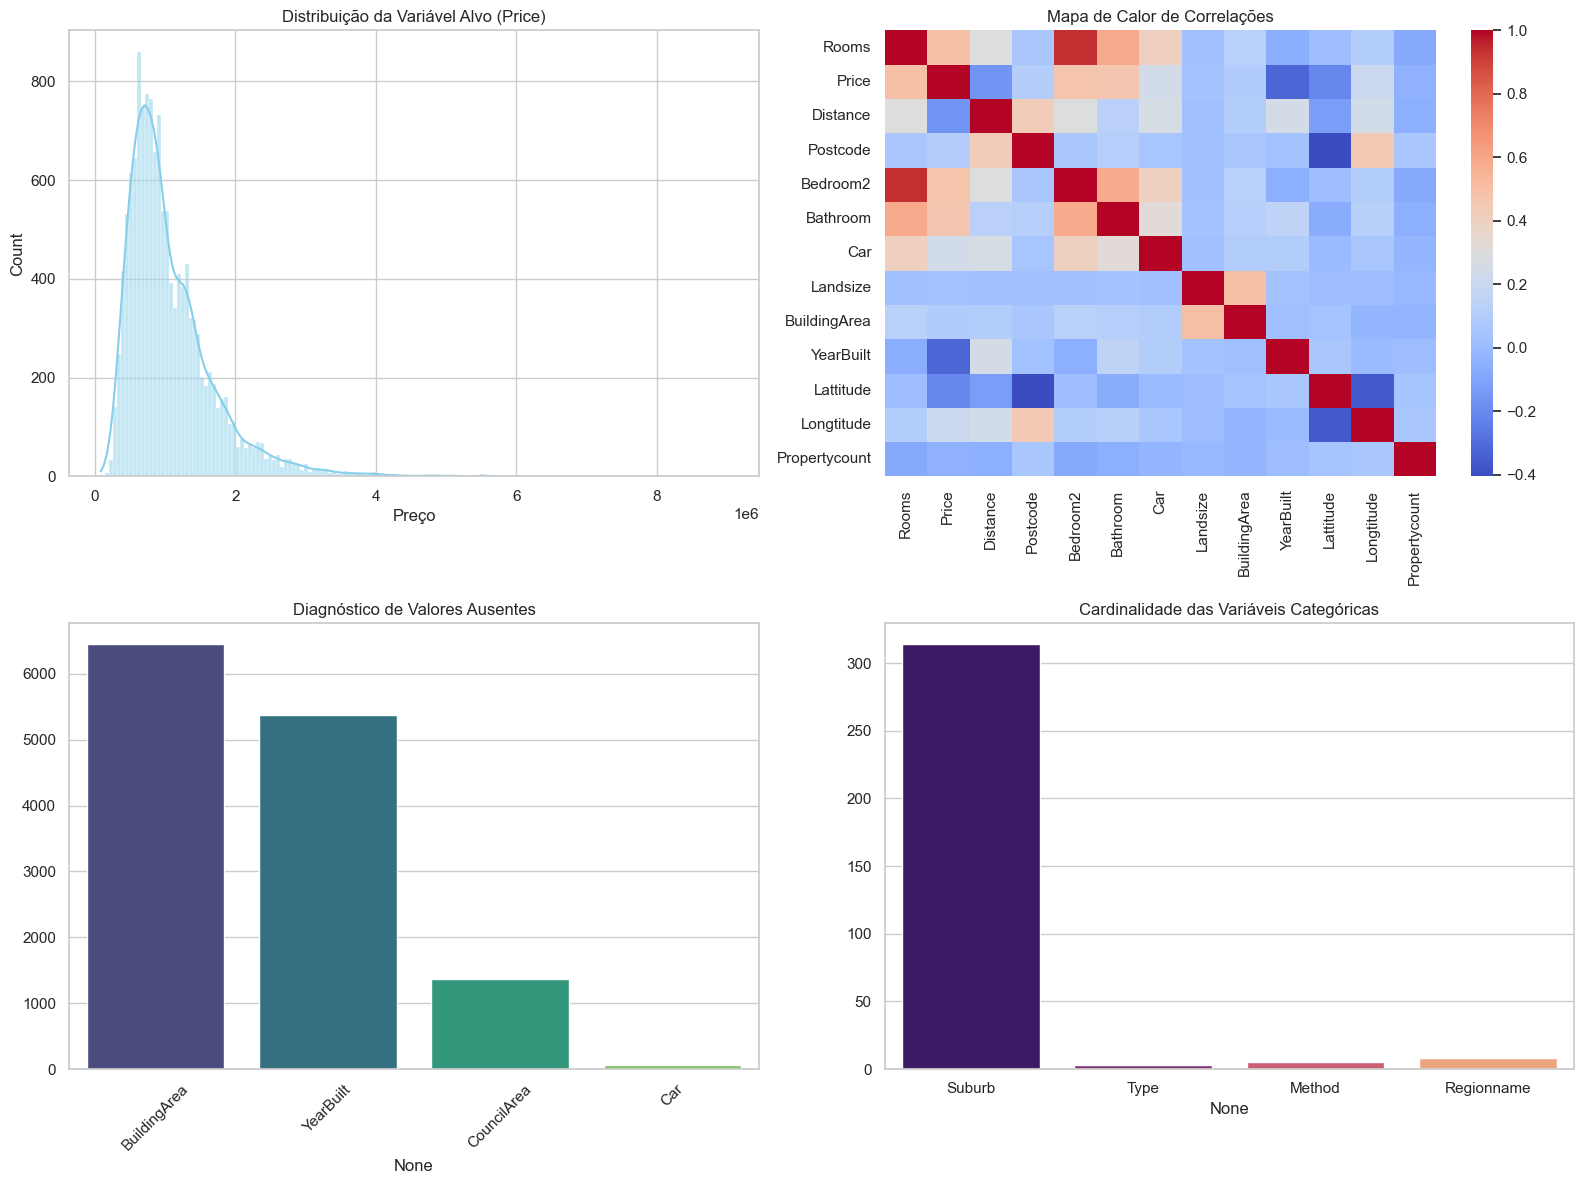


Principais Correlações com Price:
Price       1.000000
Rooms       0.496634
Bedroom2    0.475951
Bathroom    0.467038
Car         0.238979
Name: Price, dtype: float64

Total de nulos: 13256 em uma base de 13580 registros.


,Rooms,Price,Distance,Postcode,Bedroom2,Bathroom,Car,Landsize,BuildingArea,YearBuilt,Lattitude,Longtitude,Propertycount
count,13580.000000,1.358000e+04,13580.000000,13580.000000,13580.000000,13580.000000,13518.000000,13580.000000,7130.000000,8205.000000,13580.000000,13580.000000,13580.000000
mean,2.937997,1.075684e+06,10.137776,3105.301915,2.914728,1.534242,1.610075,558.416127,151.967650,1964.684217,-37.809203,144.995216,7454.417378
std,0.955748,6.393107e+05,5.868725,90.676964,0.965921,0.691712,0.962634,3990.669241,541.014538,37.273762,0.079260,0.103916,4378.581772
min,1.000000,8.500000e+04,0.000000,3000.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1196.000000,-38.182550,144.431810,249.000000
25%,2.000000,6.500000e+05,6.100000,3044.000000,2.000000,1.000000,1.000000,177.000000,93.000000,1940.000000,-37.856822,144.929600,4380.000000
50%,3.000000,9.030000e+05,9.200000,3084.000000,3.000000,1.000000,2.000000,440.000000,126.000000,1970.000000,-37.802355,145.000100,6555.000000
75%,3.000000,1.330000e+06,13.000000,3148.000000,3.000000,2.000000,2.000000,651.000000,174.000000,1999.000000,-37.756400,145.058305,10331.000000
max,10.000000,9.000000e+06,48.100000,3977.000000,20.000000,8.000000,10.000000,433014.000000,44515.000000,2018.000000,-37.408530,145.526350,21650.000000


In [27]:
# Função para resumo técnico e visual da adequação da base
def resumo_tecnico_adequacao(df, metodo_escolhido):
    print(f"--- Resumo Técnico: Adequação ao Método {metodo_escolhido} ---")
    
    # Configuração da figura para painel visual
    fig, axes = plt.subplots(2, 2, figsize=(16, 12))
    
    # 1. Distribuição da Variável Alvo (Price)
    sns.histplot(df['Price'], kde=True, ax=axes[0, 0], color='skyblue')
    axes[0, 0].set_title('Distribuição da Variável Alvo (Price)')
    axes[0, 0].set_xlabel('Preço')
    
    # 2. Matriz de Correlação (Somente Numéricas)
    df_numeric = df.select_dtypes(include=[np.number])
    sns.heatmap(df_numeric.corr(), annot=False, cmap='coolwarm', ax=axes[0, 1])
    axes[0, 1].set_title('Mapa de Calor de Correlações')
    
    # 3. Análise de Valores Ausentes
    missing = df.isnull().sum()
    missing = missing[missing > 0].sort_values(ascending=False)
    if not missing.empty:
        sns.barplot(x=missing.index, y=missing.values, ax=axes[1, 0], palette='viridis')
        axes[1, 0].set_title('Diagnóstico de Valores Ausentes')
        axes[1, 0].set_xticklabels(axes[1, 0].get_xticklabels(), rotation=45)
    
    # 4. Cardinalidade de Variáveis Categóricas Chave
    cat_cols = ['Suburb', 'Type', 'Method', 'Regionname']
    cardinality = df[cat_cols].nunique()
    sns.barplot(x=cardinality.index, y=cardinality.values, ax=axes[1, 1], palette='magma')
    axes[1, 1].set_title('Cardinalidade das Variáveis Categóricas')
    
    plt.tight_layout()
    plt.show()
    
    # Métricas textuais complementares
    correlacao_preco = df_numeric.corr()['Price'].sort_values(ascending=False)
    print(f"\nPrincipais Correlações com Price:\n{correlacao_preco.head(5)}")
    print(f"\nTotal de nulos: {df.isnull().sum().sum()} em uma base de {len(df)} registros.")

# Execução da análise de adequação
resumo_tecnico_adequacao(df, 'Regressão')

# Estatísticas descritivas
df.describe()


### Conclusão da Questão 1



A análise técnica e visual confirma que o problema central é de **Regressão**, com o objetivo de prever o `Price`. Observamos através do histograma que a variável alvo possui uma distribuição assimétrica à direita (skewed), indicando a presença de imóveis de luxo que atuam como outliers, o que exigirá modelos robustos.



O mapa de calor revelou que `Rooms`, `Bathroom` e `Bedroom2` têm as correlações mais fortes com o preço, validando a intuição de que o tamanho físico é o principal driver de valor. No entanto, a alta cardinalidade de `Suburb` (vistas no gráfico de colunas) e a grande quantidade de nulos em `BuildingArea` sugerem que uma simples Regressão Linear pode ser insuficiente. 



Portanto, a estratégia para a Lista 2 envolverá o uso de **Árvores de Decisão** e métodos de Naive Bayes adaptados, buscando capturar tanto as relações lineares de tamanho quanto as variações geográficas complexas de Melbourne.

## Questão 2 – Naive Bayes

**Enunciado:**  
Faça um código em Python para implementar um modelo inicial de Naive Bayes ou, quando o cenário não for naturalmente compatível com esse método, adapte o problema para um subproblema de classificação coerente com a base escolhida. Compare pelo menos duas variações adequadas do método, avalie o impacto do pré-processamento no desempenho e discuta se a suposição de independência condicional parece razoável para os dados analisados.

### Raciocínio
Escreva aqui, de forma objetiva, a estratégia adotada para responder à questão.

### Desenvolvimento
Implemente abaixo o código da questão.

In [28]:
# Código da Questão 2

### Conclusão da Questão 2
Registre aqui as principais interpretações e conclusões obtidas com base nos resultados.

## Questão 3 – Regressão

**Enunciado:**  
Faça um código em Python para construir um problema de Regressão a partir da base escolhida, seja utilizando o alvo original quando ele for numérico, seja definindo uma variável quantitativa derivada coerente com o cenário. Implemente pelo menos dois modelos de regressão, compare desempenho com métricas adequadas e analise os resíduos, discutindo se há sinais de não linearidade, heterocedasticidade ou influência excessiva de outliers.

### Raciocínio
Escreva aqui, de forma objetiva, a estratégia adotada para responder à questão.

### Desenvolvimento
Implemente abaixo o código da questão.

In [29]:
# Código da Questão 3

### Conclusão da Questão 3
Registre aqui as principais interpretações e conclusões obtidas com base nos resultados.

## Questão 4 – Árvore de Decisão

**Enunciado:**  
Faça um código em Python para treinar e avaliar um modelo de Árvore de Decisão adequado ao problema da base escolhida. Controle profundidade, critérios de divisão e tamanho mínimo de amostras por nó, registrando os resultados em tabela. Depois, interprete a árvore gerada, identifique as variáveis mais relevantes nas divisões e discuta se a interpretabilidade do modelo compensa eventuais perdas de desempenho em comparação com os métodos testados anteriormente.

### Raciocínio
Escreva aqui, de forma objetiva, a estratégia adotada para responder à questão.

### Desenvolvimento
Implemente abaixo o código da questão.

In [30]:
# Código da Questão 4

### Conclusão da Questão 4
Registre aqui as principais interpretações e conclusões obtidas com base nos resultados.

## Questão 5 – Comparação entre modelos

**Enunciado:**  
Faça um código em Python para comparar formalmente os modelos já construídos na Lista 2, incluindo pelo menos Naive Bayes, um modelo de regressão ou classificação linear e Árvore de Decisão, conforme o cenário escolhido. Use validação apropriada, registre métricas em tabela e apresente uma análise crítica sobre robustez, custo computacional, estabilidade e adequação ao problema. Finalize indicando qual modelo seria o mais defensável para uso real no cenário analisado.

### Raciocínio
Escreva aqui, de forma objetiva, a estratégia adotada para responder à questão.

### Desenvolvimento
Implemente abaixo o código da questão.

In [31]:
# Código da Questão 5

### Conclusão da Questão 5
Registre aqui as principais interpretações e conclusões obtidas com base nos resultados.

## Questão 6 – Séries Temporais

**Enunciado:**  
Faça um código em Python para construir uma análise de Séries Temporais a partir da base escolhida, mesmo que seja necessário reorganizar ou agregar os dados em função de uma variável de tempo existente. Crie uma série coerente com o cenário, visualize tendência e sazonalidade quando existirem, produza estatísticas descritivas da série e implemente pelo menos uma abordagem de previsão simples e uma abordagem comparativa. Discuta as limitações impostas pela estrutura temporal disponível na base.

### Raciocínio
Escreva aqui, de forma objetiva, a estratégia adotada para responder à questão.

### Desenvolvimento
Implemente abaixo o código da questão.

In [32]:
# Código da Questão 6

### Conclusão da Questão 6
Registre aqui as principais interpretações e conclusões obtidas com base nos resultados.

## Questão 7 – Análise de Redes

**Enunciado:**  
Faça um código em Python para construir uma representação de Rede a partir da base escolhida ou de atributos derivados dela. Defina nós e arestas de forma coerente com o cenário, gere o grafo em Python e calcule medidas como grau, centralidade ou comunidades, quando fizer sentido. Depois, interprete os resultados e discuta se a análise de redes realmente acrescenta valor ao problema ou se sua aplicação no caso escolhido é metodologicamente fraca.

### Raciocínio
Escreva aqui, de forma objetiva, a estratégia adotada para responder à questão.

### Desenvolvimento
Implemente abaixo o código da questão.

In [33]:
# Código da Questão 7

### Conclusão da Questão 7
Registre aqui as principais interpretações e conclusões obtidas com base nos resultados.

## Questão 8 – Meta-aprendizagem

**Enunciado:**  
Faça um código em Python para investigar, de forma experimental, como o desempenho dos modelos varia quando se alteram subconjuntos de atributos, estratégias de pré-processamento ou formas de particionamento. Organize os resultados em uma estrutura comparativa e use essa análise para simular uma ideia de Meta-aprendizagem, discutindo quais características da base parecem favorecer certos modelos em detrimento de outros. Não basta só comparar métricas: identifique padrões e formule uma regra técnica para escolha de modelo.

### Raciocínio
Escreva aqui, de forma objetiva, a estratégia adotada para responder à questão.

### Desenvolvimento
Implemente abaixo o código da questão.

In [34]:
# Código da Questão 8

### Conclusão da Questão 8
Registre aqui as principais interpretações e conclusões obtidas com base nos resultados.

## Questão 9 – Visualização de Dados

**Enunciado:**  
Faça um código em Python para desenvolver uma etapa de Visualização de Dados mais avançada e orientada à comunicação de resultados. Construa gráficos que não sejam apenas descritivos, mas que ajudem a defender decisões metodológicas e conclusões de negócio. Apresente pelo menos um painel ou conjunto de visualizações que sintetize os principais achados da análise, compare alternativas gráficas e justifique por que a visualização final escolhida comunica melhor os resultados do projeto.

### Raciocínio
Escreva aqui, de forma objetiva, a estratégia adotada para responder à questão.

### Desenvolvimento
Implemente abaixo o código da questão.

In [35]:
# Código da Questão 9

### Conclusão da Questão 9
Registre aqui as principais interpretações e conclusões obtidas com base nos resultados.

## Questão 10 – Consolidação da solução

**Enunciado:**  
Faça um código em Python para consolidar toda a análise da Lista 2 em um fluxo final reutilizável. Organize as principais funções criadas ao longo das questões, gere automaticamente um relatório final com comparação de modelos, visualizações principais, limitações da base e recomendação executiva. Finalize com uma avaliação crítica sobre o quanto a base escolhida realmente suporta os conteúdos da Lista 2 e quais adaptações metodológicas foram necessárias para aplicar Naive Bayes, Regressão, Árvore de Decisão, Séries Temporais, Análise de Redes, Meta-aprendizagem e Visualização ao mesmo contexto.

### Raciocínio
Escreva aqui, de forma objetiva, a estratégia adotada para responder à questão.

### Desenvolvimento
Implemente abaixo o código da questão.

In [36]:
# Código da Questão 10

### Conclusão da Questão 1



A análise técnica e visual confirma que o problema central é de **Regressão**, com o objetivo de prever o `Price`. Observamos através do histograma que a variável alvo possui uma distribuição assimétrica à direita (skewed), indicando a presença de imóveis de luxo que atuam como outliers, o que exigirá modelos robustos.



O mapa de calor revelou que `Rooms`, `Bathroom` e `Bedroom2` têm as correlações mais fortes com o preço, validando a intuição de que o tamanho físico é o principal driver de valor. No entanto, a alta cardinalidade de `Suburb` (vistas no gráfico de colunas) e a grande quantidade de nulos em `BuildingArea` sugerem que uma simples Regressão Linear pode ser insuficiente. 



Portanto, a estratégia para a Lista 2 envolverá o uso de **Árvores de Decisão** e métodos de Naive Bayes adaptados, buscando capturar tanto as relações lineares de tamanho quanto as variações geográficas complexas de Melbourne.

## Conclusão Final

Apresente uma síntese geral do trabalho, destacando:

- principais decisões metodológicas;
- comparação entre os modelos utilizados;
- limitações da base escolhida;
- avaliação final da adequação da solução ao cenário.

**Bom trabalho!**